In [ ]:

#Good
#Test
#Hello team
# TEST 2
#Step 0 - Import and Load the Excel File
#KK test
import pandas as pd

# Read the Excel file
df = pd.read_excel(r"C:\Users\Mahmoud Gobran\00_Ironhack\Projects\GSAF5.xls")

# Show basic info
print(df.shape)
print(df.columns)
df.head()


(7012, 23)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,2025-04-19 00:00:00,2025.0,Unprovoked,Maldives,Kulhudhuffushi City,Haa Dhaalu atoll,snorkeling,Unknown Male,M,30,...,Not stated,Todd Smith: The edition: https://en.sun.mv/96031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-04-12 00:00:00,2025.0,Unprovoked,USA,Florida,Everglades National Park Flamingo Lodge Highwa...,Undisclosed,Unknown Male,M,?,...,Not stated,Kevin McMurray Trackingsharks.com: Florida New...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-03-26 00:00:00,2025.0,Unprovoked,Australia,WA,Sandtrax Port Beach North Fremantle Perth,Swimming,Unknown Male,M,30+,...,1.5m Tiger shark,Kevin McMurray Trackingsharks.com: www.surfer....,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-03-10 00:00:00,2025.0,Unprovoked,Australia,WA,Duke of Orleans Bay,Surfing,Steven Jeffrey Payne,M,37,...,Great White Shark,Bob Myatt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-03-07 00:00:00,2025.0,Unprovoked,Australia,NSW,Gunyah beach Bundeena Port Hacking,Swimming,Mangyong Zhang,F,56,...,Bull shark,Bob Myatt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
#Step 1: Drop Useless Columns

columns_to_drop = ['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22']
df = df.drop(columns=columns_to_drop)

print(df.shape)
print(df.columns)
df.head()

(7012, 15)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source'],
      dtype='object')


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source
0,2025-04-19 00:00:00,2025.0,Unprovoked,Maldives,Kulhudhuffushi City,Haa Dhaalu atoll,snorkeling,Unknown Male,M,30,Injuries to right shoulder,N,Not stated,Not stated,Todd Smith: The edition: https://en.sun.mv/96031
1,2025-04-12 00:00:00,2025.0,Unprovoked,USA,Florida,Everglades National Park Flamingo Lodge Highwa...,Undisclosed,Unknown Male,M,?,Injuries to right hand and arm,N,1500hrs,Not stated,Kevin McMurray Trackingsharks.com: Florida New...
2,2025-03-26 00:00:00,2025.0,Unprovoked,Australia,WA,Sandtrax Port Beach North Fremantle Perth,Swimming,Unknown Male,M,30+,Bumping to the body,N,1430hrs,1.5m Tiger shark,Kevin McMurray Trackingsharks.com: www.surfer....
3,2025-03-10 00:00:00,2025.0,Unprovoked,Australia,WA,Duke of Orleans Bay,Surfing,Steven Jeffrey Payne,M,37,Missing body not recovered,Y,1210 hrs,Great White Shark,Bob Myatt
4,2025-03-07 00:00:00,2025.0,Unprovoked,Australia,NSW,Gunyah beach Bundeena Port Hacking,Swimming,Mangyong Zhang,F,56,Serious lacerations above right knee.,N,1340hrs,Bull shark,Bob Myatt


In [48]:
#Step 2: Fix 'Date' and 'Year'
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

#change date formate from (year, month, day) to (day, month, year)
df['Date'] = df['Date'].dt.strftime('%d-%m-%Y')

# Drop rows where 'Year' is missing
df = df.dropna(subset=['Year'])

# Convert 'Year' to integer
df['Year'] = df['Year'].astype(int)

# Check sample
print(df[['Date', 'Year']].head())
print(df.shape)

#df.head()

         Date  Year
0  19-04-2025  2025
1  12-04-2025  2025
2  26-03-2025  2025
3  10-03-2025  2025
4  07-03-2025  2025
(7010, 15)


In [49]:
#Step 3 - Check Missing Values
# Calculate missing data for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Round the missing percentage to two decimal places
missing_percentage = missing_percentage.round(2)

# Put it into a table and sort it
missing_table = missing_percentage.sort_values(ascending=False).to_frame('Missing Percentage')

# Show the missing data
print(missing_table)

           Missing Percentage
Time                    50.27
Species                 44.65
Age                     42.70
Date                    12.47
Activity                 8.35
Sex                      8.26
Location                 8.06
Fatal Y/N                7.99
State                    6.92
Name                     3.12
Country                  0.71
Injury                   0.50
Source                   0.27
Type                     0.26
Year                     0.00


In [71]:
df['Time'].describe()

count          3486
unique          444
top       Afternoon
freq            215
Name: Time, dtype: object

In [79]:
pd.options.display.max_rows=500

In [80]:
df['Time'].value_counts()

Time
Afternoon                                                                215
11h00                                                                    140
Morning                                                                  135
15h00                                                                    127
16h00                                                                    123
12h00                                                                    122
14h00                                                                    115
16h30                                                                     88
13h00                                                                     85
17h30                                                                     83
17h00                                                                     81
14h30                                                                     76
18h00                                                                  

In [77]:
df['Time'].unique()

array(['Not stated', '1500hrs', '1430hrs', '1210 hrs', '1340hrs',
       'Unknown', '1300hrs', '0815hrs', '1503hrs', '1830hrs', '1645 hrs',
       '1711hrs', '1600hrs', '1330hrs', '1615hr', '1710hr', '?', '1637hr',
       'AM', '16.30hrs', '1600hr', '11.30hr', '1100hr', '1735hr',
       '11hr15', '16hr15', 'after 1200hr', '1400hr', 15.5, '13h15', '9h',
       1300, '14h', '15h30', '13h30', '9h15', 'Not advised', '13h40',
       '12h30', '16h00', nan, '11h30', '06h30', '20h00', '13h00', '11h12',
       '16h30', '15h00', '02h00', '09h15', 'Early Morning', '16h32',
       '11h00', 'Morning', '10h30', '13h20', '14h00', '09h00', '10h20',
       '15h05', '17h00', '15h45', '07h45', '10h40', '07h50', '01h00',
       '10h00', 'Afternoon', '19h30', 'Evening', '17h50', '09h30',
       '08h45', '"Midday"', '16h25', '13h55', '13h50', '17h20', '13h45',
       '10h10', '14h35', 'Night', '1500h ', '19h15', '11h20', '07h15',
       '07h00', '18h00', '08h00', '14h20', '17h30', '07h20', '14h50',
       '

In [76]:
import numpy as np
df['Time'] = df['Time'].str[:2].replace("No", np.nan).astype(float)

ValueError: could not convert string to float: 'Un'

In [ ]:
df_no_time = df.dropna(subset=['Time'])


In [ ]:
#Step 4: Remove Columns with Mostly Missing Data
# Show how many missing values per column
missing_counts = df.isnull().sum()

# Set threshold: remove columns with more than 80% missing values
threshold = len(df) * 0.8
df = df.loc[:, missing_counts < threshold]
print(df.shape)
print(df.columns)
df.head()

(7010, 15)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source'],
      dtype='object')


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source
0,19-04-2025,2025,Unprovoked,Maldives,Kulhudhuffushi City,Haa Dhaalu atoll,snorkeling,Unknown Male,M,30,Injuries to right shoulder,N,Not stated,Not stated,Todd Smith: The edition: https://en.sun.mv/96031
1,12-04-2025,2025,Unprovoked,USA,Florida,Everglades National Park Flamingo Lodge Highwa...,Undisclosed,Unknown Male,M,?,Injuries to right hand and arm,N,1500hrs,Not stated,Kevin McMurray Trackingsharks.com: Florida New...
2,26-03-2025,2025,Unprovoked,Australia,WA,Sandtrax Port Beach North Fremantle Perth,Swimming,Unknown Male,M,30+,Bumping to the body,N,1430hrs,1.5m Tiger shark,Kevin McMurray Trackingsharks.com: www.surfer....
3,10-03-2025,2025,Unprovoked,Australia,WA,Duke of Orleans Bay,Surfing,Steven Jeffrey Payne,M,37,Missing body not recovered,Y,1210 hrs,Great White Shark,Bob Myatt
4,07-03-2025,2025,Unprovoked,Australia,NSW,Gunyah beach Bundeena Port Hacking,Swimming,Mangyong Zhang,F,56,Serious lacerations above right knee.,N,1340hrs,Bull shark,Bob Myatt


In [7]:
#Step 5: Remove Duplicates and Clean Column Names
# Drop duplicate rows
df = df.drop_duplicates()

# Clean column names: strip spaces, make lowercase, replace spaces with underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.shape)
print(df.columns)
df.head()

(7009, 15)
Index(['date', 'year', 'type', 'country', 'state', 'location', 'activity',
       'name', 'sex', 'age', 'injury', 'fatal_y/n', 'time', 'species',
       'source'],
      dtype='object')


,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y/n,time,species,source
0,19-04-2025,2025,Unprovoked,Maldives,Kulhudhuffushi City,Haa Dhaalu atoll,snorkeling,Unknown Male,M,30,Injuries to right shoulder,N,Not stated,Not stated,Todd Smith: The edition: https://en.sun.mv/96031
1,12-04-2025,2025,Unprovoked,USA,Florida,Everglades National Park Flamingo Lodge Highwa...,Undisclosed,Unknown Male,M,?,Injuries to right hand and arm,N,1500hrs,Not stated,Kevin McMurray Trackingsharks.com: Florida New...
2,26-03-2025,2025,Unprovoked,Australia,WA,Sandtrax Port Beach North Fremantle Perth,Swimming,Unknown Male,M,30+,Bumping to the body,N,1430hrs,1.5m Tiger shark,Kevin McMurray Trackingsharks.com: www.surfer....
3,10-03-2025,2025,Unprovoked,Australia,WA,Duke of Orleans Bay,Surfing,Steven Jeffrey Payne,M,37,Missing body not recovered,Y,1210 hrs,Great White Shark,Bob Myatt
4,07-03-2025,2025,Unprovoked,Australia,NSW,Gunyah beach Bundeena Port Hacking,Swimming,Mangyong Zhang,F,56,Serious lacerations above right knee.,N,1340hrs,Bull shark,Bob Myatt


In [9]:
#Step 6: Fix String Columns (Remove Extra Spaces, Capitalize)
# Strip whitespace and capitalize first letter in text columns
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.capitalize()
    print(df.shape)
print(df.columns)
df.head()

(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
(7009, 15)
Index(['date', 'year', 'type', 'country', 'state', 'location', 'activity',
       'name', 'sex', 'age', 'injury', 'fatal_y/n', 'time', 'species',
       'source'],
      dtype='object')


,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y/n,time,species,source
0,19-04-2025,2025,Unprovoked,Maldives,Kulhudhuffushi city,Haa dhaalu atoll,Snorkeling,Unknown male,M,30,Injuries to right shoulder,N,Not stated,Not stated,Todd smith: the edition: https://en.sun.mv/96031
1,12-04-2025,2025,Unprovoked,Usa,Florida,Everglades national park flamingo lodge highwa...,Undisclosed,Unknown male,M,?,Injuries to right hand and arm,N,1500hrs,Not stated,Kevin mcmurray trackingsharks.com: florida new...
2,26-03-2025,2025,Unprovoked,Australia,Wa,Sandtrax port beach north fremantle perth,Swimming,Unknown male,M,30+,Bumping to the body,N,1430hrs,1.5m tiger shark,Kevin mcmurray trackingsharks.com: www.surfer.com
3,10-03-2025,2025,Unprovoked,Australia,Wa,Duke of orleans bay,Surfing,Steven jeffrey payne,M,37,Missing body not recovered,Y,1210 hrs,Great white shark,Bob myatt
4,07-03-2025,2025,Unprovoked,Australia,Nsw,Gunyah beach bundeena port hacking,Swimming,Mangyong zhang,F,56,Serious lacerations above right knee.,N,1340hrs,Bull shark,Bob myatt


In [11]:
#Step 7: Save Cleaned Data
# Save cleaned data to new Excel file
df_cleaned=df
df_cleaned.to_excel(r"C:\Users\Mahmoud Gobran\00_Ironhack\Projects\cleaned_shark_attacks.xlsx", index=False)


In [ ]:
#                                   Exploratory Data Analysis (EDA)

In [12]:
#Step 1: Reload the Cleaned Data
import pandas as pd

# Load cleaned data
df = pd.read_excel(r"C:\Users\Mahmoud Gobran\00_Ironhack\Projects\cleaned_shark_attacks.xlsx")


In [13]:
#Step 2: Check Overall Structure
# Shape: rows and columns
print("Shape:", df.shape)

# Basic info
print(df.info())

# Quick preview
df.head()


Shape: (7009, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7009 entries, 0 to 7008
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       7009 non-null   object
 1   year       7009 non-null   int64 
 2   type       7009 non-null   object
 3   country    7009 non-null   object
 4   state      7009 non-null   object
 5   location   7008 non-null   object
 6   activity   7007 non-null   object
 7   name       7009 non-null   object
 8   sex        7009 non-null   object
 9   age        7005 non-null   object
 10  injury     7008 non-null   object
 11  fatal_y/n  7009 non-null   object
 12  time       7004 non-null   object
 13  species    6999 non-null   object
 14  source     7008 non-null   object
dtypes: int64(1), object(14)
memory usage: 821.5+ KB
None


,date,year,type,country,state,location,activity,name,sex,age,injury,fatal_y/n,time,species,source
0,19-04-2025,2025,Unprovoked,Maldives,Kulhudhuffushi city,Haa dhaalu atoll,Snorkeling,Unknown male,M,30,Injuries to right shoulder,N,Not stated,Not stated,Todd smith: the edition: https://en.sun.mv/96031
1,12-04-2025,2025,Unprovoked,Usa,Florida,Everglades national park flamingo lodge highwa...,Undisclosed,Unknown male,M,?,Injuries to right hand and arm,N,1500hrs,Not stated,Kevin mcmurray trackingsharks.com: florida new...
2,26-03-2025,2025,Unprovoked,Australia,Wa,Sandtrax port beach north fremantle perth,Swimming,Unknown male,M,30+,Bumping to the body,N,1430hrs,1.5m tiger shark,Kevin mcmurray trackingsharks.com: www.surfer.com
3,10-03-2025,2025,Unprovoked,Australia,Wa,Duke of orleans bay,Surfing,Steven jeffrey payne,M,37,Missing body not recovered,Y,1210 hrs,Great white shark,Bob myatt
4,07-03-2025,2025,Unprovoked,Australia,Nsw,Gunyah beach bundeena port hacking,Swimming,Mangyong zhang,F,56,Serious lacerations above right knee.,N,1340hrs,Bull shark,Bob myatt


In [14]:
#Step 3: Count Missing Values
# Count of missing values per column
df.isnull().sum()


date          0
year          0
type          0
country       0
state         0
location      1
activity      2
name          0
sex           0
age           4
injury        1
fatal_y/n     0
time          5
species      10
source        1
dtype: int64

In [50]:
df.nunique()

Date         5129
Year          261
Type           12
Country       242
State         926
Location     4570
Activity     1604
Name         5740
Sex            10
Age           249
Injury       4138
Fatal Y/N      12
Time          444
Species      1712
Source       5355
dtype: int64

In [68]:
filter_ = df[['Date', 'Location', 'Name', 'Injury']].duplicated(keep=False)

filter_[1889:]

1890     True
1891    False
1892    False
1893    False
1894    False
        ...  
7007    False
7008    False
7009    False
7010    False
7011    False
Length: 5121, dtype: bool

In [ ]:
df > 3

In [ ]:
df[filter_][['Date', 'Location', 'Name', 'Injury']]

In [70]:
df[filter_]

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source
1889,06-09-2008,2008,Unprovoked,USA,Florida,"Ponce Inlet, New Smyrna Beach, Volusia County",Surfing,male,M,43,Minor injury to foot,N,12h00,NaN,"S. Petersohn, GSAF"
1890,06-09-2008,2008,Unprovoked,USA,Florida,"Ponce Inlet, New Smyrna Beach, Volusia County",Surfing,male,M,15,Minor injury to foot,N,12h00,NaN,"S. Petersohn, GSAF"
4405,NaN,1964,Unprovoked,PAPUA NEW GUINEA,New Britain,NaN,Fishing,male,M,NaN,FATAL,Y,NaN,Tiger shark,"Oldham Evening Chronicle, 1/6/1964"
5385,NaN,1943,Unprovoked,USA,Hawaii,"Midway Island, Northwestern Hawaiian Islands",Spearfishing,2 males,M,NaN,Calf nipped in each case,N,NaN,"""small sharks""",W. M. Chapman
5386,NaN,1943,Unprovoked,USA,Hawaii,"Midway Island, Northwestern Hawaiian Islands",Spearfishing,2 males,M,NaN,Calf nipped in each case,N,NaN,"""small sharks""",W. M. Chapman
5407,NaN,1942,Sea Disaster,BAY OF BENGAL,NaN,NaN,A 210-ton brig was sunk by a Japanese submarin...,2 males,M,NaN,FATAL,Y,NaN,NaN,"Canberra Times, 6/11/1942"
5424,01-01-1970,1942,Sea Disaster,NaN,NaN,NaN,Jumped overboard from torpedoed Panamanian fre...,male,M,NaN,FATAL,Y,NaN,NaN,"V.M. Coppleson (1962), p.258"
5531,NaN,1937,Sea Disaster,SOLOMON ISLANDS,NaN,NaN,Two canoes with 14 aboard blown to sea in a st...,NaN,M,NaN,FATAL,Y,NaN,NaN,"The Argus, 11/6/1937"
5912,01-01-1923,1923,Provoked,USA,New Jersey,Ocean City (offshore),Hoisting shark aboard fishing boat,male,M,NaN,Shark's tail broke his leg. PROVOKED INCIDENT,N,NaN,NaN,"Ref in New York Herald Tribune, 8/23/1960; V.M..."
5913,01-01-1923,1922,Provoked,USA,New Jersey,Ocean City (offshore),Hoisting shark aboard fishing boat,male,M,NaN,Shark's tail broke his leg. PROVOKED INCIDENT,N,NaN,NaN,"Ref in New York Herald Tribune, 8/23/1960; V.M..."


In [55]:
duplicates = df[df.duplicated(subset=['Date', 'Location', 'Name', 'Injury'])]
print(duplicates)

            Date  Year        Type         Country              State  \
1890  06-09-2008  2008  Unprovoked             USA            Florida   
5386         NaN  1943  Unprovoked             USA             Hawaii   
5913  01-01-1923  1922    Provoked             USA         New Jersey   
6225         NaN  1903  Unprovoked           CRETE                NaN   
6313         NaN  1897  Unprovoked             NaN  Mediterranean Sea   
6326  01-01-1970  1896  Unprovoked             USA            Florida   
6410  01-01-1890  1890  Unprovoked           INDIA         Tamil Nadu   
6472         NaN  1885  Unprovoked             NaN                NaN   
6504         NaN  1882  Unprovoked  ATLANTIC OCEAN                NaN   
6629         NaN  1867  Unprovoked           EGYPT                NaN   
6664         NaN  1863  Unprovoked          GREECE              Corfu   
6751         NaN  1846  Unprovoked          AFRICA                NaN   
6832         NaN  1802  Unprovoked           INDIA 

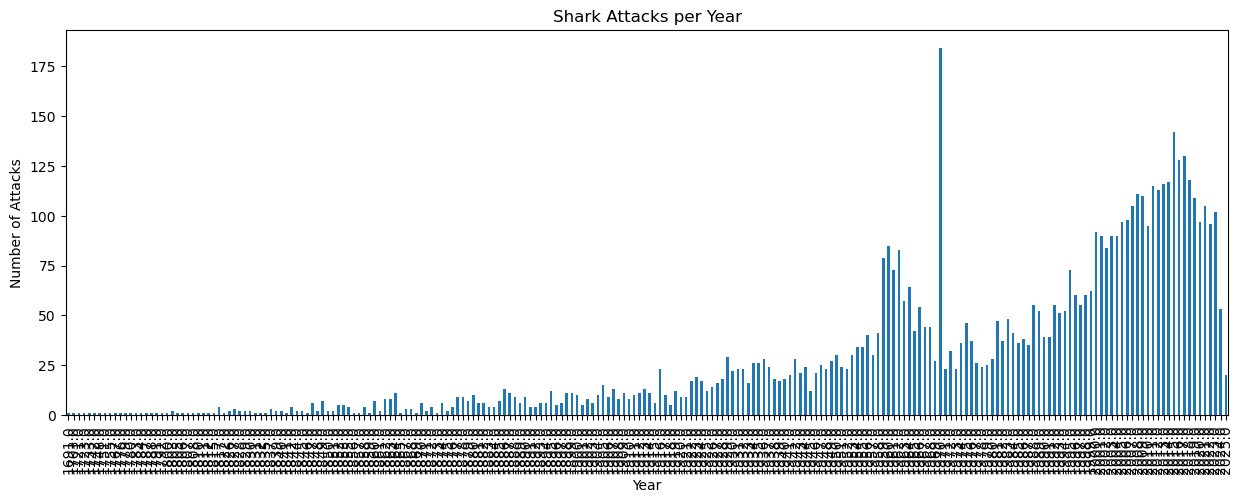

In [19]:
#Step 4: Analyze Shark Attack Frequency by Year
# Convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)

# Extract year from date
df['year'] = df['date'].dt.year

# Count attacks per year
attacks_per_year = df['year'].value_counts().sort_index() #df['year']: selects the year column .value_counts(): counts how many times each year appears + .sort_index(): sorts the years in order (ascending)

#print(df.head())

# Plot
import matplotlib.pyplot as plt

attacks_per_year.plot(kind='bar', figsize=(15,5))
plt.title('Shark Attacks per Year')
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.show()


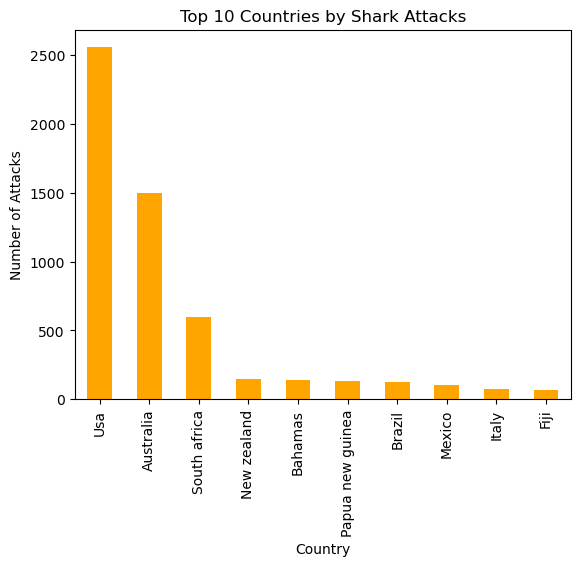

In [20]:
#Step 5: Top Countries with Most Attacks
# Count by country
df['country'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Countries by Shark Attacks')
plt.xlabel('Country')
plt.ylabel('Number of Attacks')
plt.show()


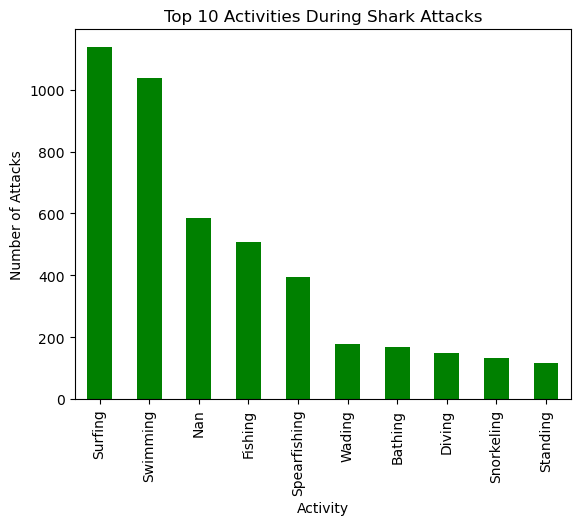

In [21]:
#Step 6: Common Activities When Attacked
# Count top 10 activities
df['activity'].value_counts().head(10).plot(kind='bar', color='green')
plt.title('Top 10 Activities During Shark Attacks')
plt.xlabel('Activity')
plt.ylabel('Number of Attacks')
plt.show()


In [23]:
print(df.columns)


Index(['date', 'year', 'type', 'country', 'state', 'location', 'activity',
       'name', 'sex', 'age', 'injury', 'fatal_y/n', 'time', 'species',
       'source'],
      dtype='object')


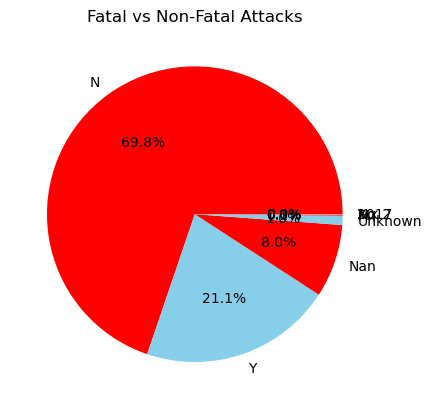

In [24]:
#Step 7: Fatal vs Non-Fatal Attacks

# Count fatal vs non-fatal
df['fatal_y/n'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['red', 'skyblue'])
plt.title('Fatal vs Non-Fatal Attacks')
plt.ylabel('')
plt.show()


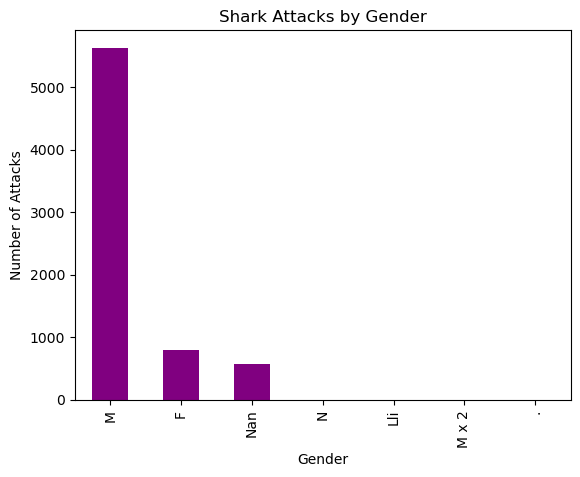

In [25]:
#Step 8: Gender Distribution (if gender column exists)
# Count attacks by gender
df['sex'].value_counts().plot(kind='bar', color='purple')
plt.title('Shark Attacks by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Attacks')
plt.show()


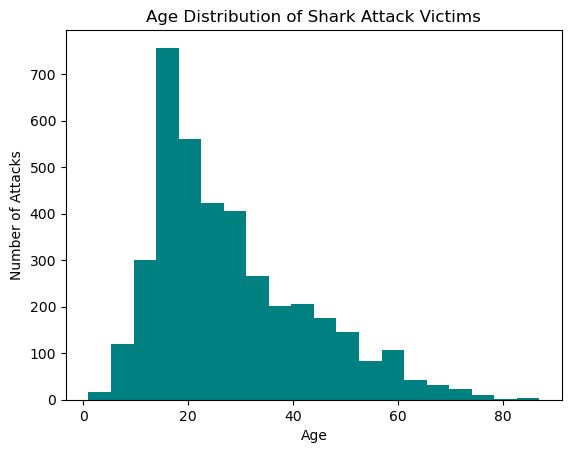

In [26]:
#Step 9: Age Distribution (if age column is clean)
# Convert age to numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Plot histogram
df['age'].dropna().astype(int).plot(kind='hist', bins=20, color='teal')
plt.title('Age Distribution of Shark Attack Victims')
plt.xlabel('Age')
plt.ylabel('Number of Attacks')
plt.show()


In [28]:
#Step 10: Pivot Table of Fatal Attacks by Country

# Create a pivot table to count fatal vs non-fatal attacks per country
pivot = df.pivot_table(
    values='date', 
    index='country', 
    columns='fatal_y/n', 
    aggfunc='count', 
    fill_value=0
)

# Sort by number of fatal attacks (column 'Y') in descending order
pivot = pivot.sort_values(by='Y', ascending=False)

# Display top 10 countries
pivot.head(10)


fatal_y/n,2017,F,M,N,Nan,Nq,Unknown,Y,Y x 2
country,,,,,,,,,
Australia,0,1,0,948,99,0,18,269,0
Usa,0,1,0,2033,170,1,18,170,1
South africa,0,0,1,403,59,0,2,97,0
Papua new guinea,0,0,0,66,1,0,2,45,0
Mexico,0,0,0,38,10,0,0,37,0
Brazil,0,0,0,70,6,0,2,37,0
Philippines,0,0,0,20,3,0,1,32,0
Reunion,0,0,0,29,0,0,0,27,0
New caledonia,0,1,0,36,1,0,0,25,0


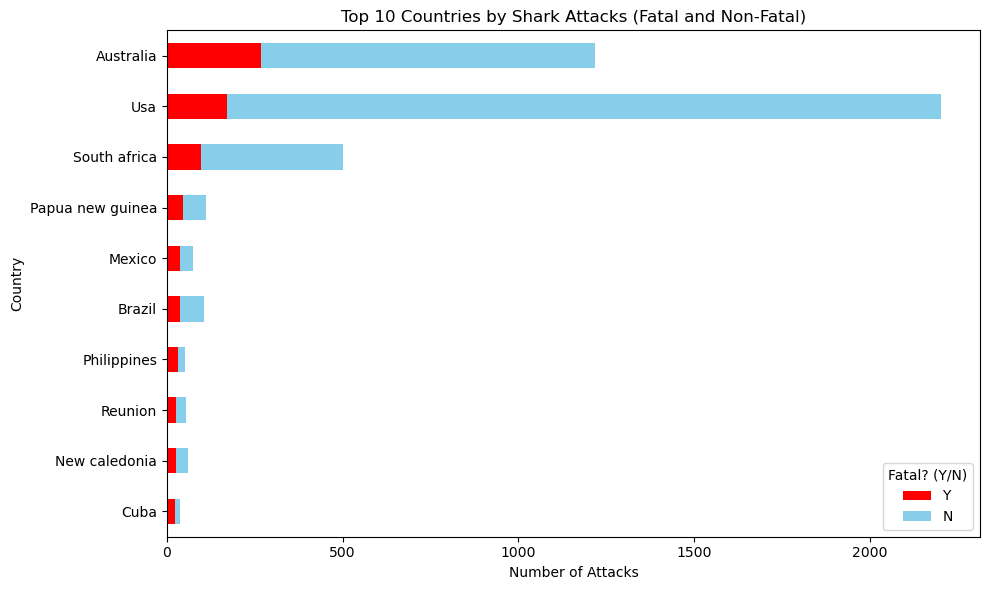

In [ ]:
#Step 11: Plot Fatal vs Non-Fatal Attacks by Country (Top 10)
import matplotlib.pyplot as plt

# Select top 10 countries with most fatal attacks
top10 = pivot.head(10)

# Plot
top10[['Y', 'N']].plot(kind='barh', stacked=True, figsize=(10, 6), color=['red', 'skyblue'])

plt.xlabel('Number of Attacks')
plt.ylabel('Country')
plt.title('Top 10 Countries by Shark Attacks (Fatal and Non-Fatal)')
plt.legend(title='Fatal? (Y/N)')
plt.gca().invert_yaxis()  # So the country with most attacks is on top
plt.tight_layout()
plt.show()

#Explanation: 
# plot(kind='barh', stacked=True): Horizontal stacked bar chart to compare 'Y' and 'N' together.

#[['Y', 'N']]: Only plots the fatal and non-fatal columns.

#invert_yaxis(): Puts the highest on top.

#tight_layout(): Prevents label cutoff.
# This helps you visually compare how dangerous shark attacks are in each country.


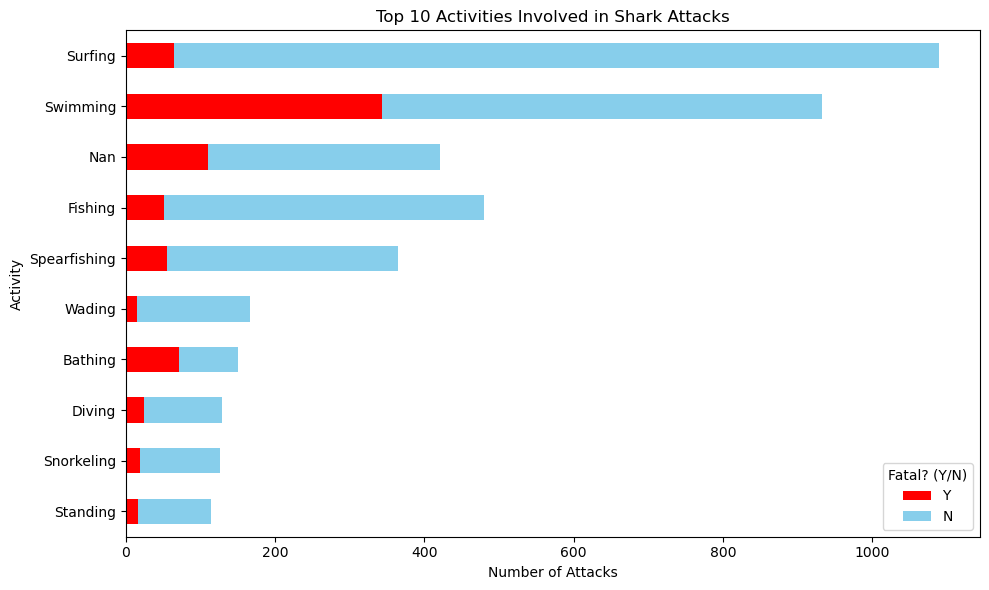

In [ ]:
#Step 12: Analyze Attacks by Activity (Top 10)
#We'll look at the top 10 most common activities during shark attacks, and check if they were fatal or not.

# Group by 'activity' and 'fatal_y/n'
activity_fatal = df.groupby(['activity', 'fatal_y/n']).size().unstack(fill_value=0)

# Sort by total attacks and select top 10
top10_activities = activity_fatal.sum(axis=1).sort_values(ascending=False).head(10)
activity_top10 = activity_fatal.loc[top10_activities.index]

# Plot
activity_top10[['Y', 'N']].plot(kind='barh', stacked=True, figsize=(10, 6), color=['red', 'skyblue'])

plt.xlabel('Number of Attacks')
plt.ylabel('Activity')
plt.title('Top 10 Activities Involved in Shark Attacks')
plt.legend(title='Fatal? (Y/N)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#Explanation
#groupby(['activity', 'fatal_y/n']): Groups attacks by activity and whether they were fatal.

#unstack(): Turns 'fatal_y/n' into columns.

#sum(axis=1): Total attacks per activity.

#loc[top10_activities.index]: Gets top 10 for plotting.

#Uses same chart structure as countries for consistency.


time
Nan          3523
Afternoon     215
11h00         140
Morning       136
15h00         127
16h00         123
12h00         122
14h00         116
16h30          88
13h00          85
17h30          83
17h00          81
14h30          76
11h30          75
18h00          75
10h00          73
15h30          73
13h30          70
Night          65
10h30          61
Name: count, dtype: int64


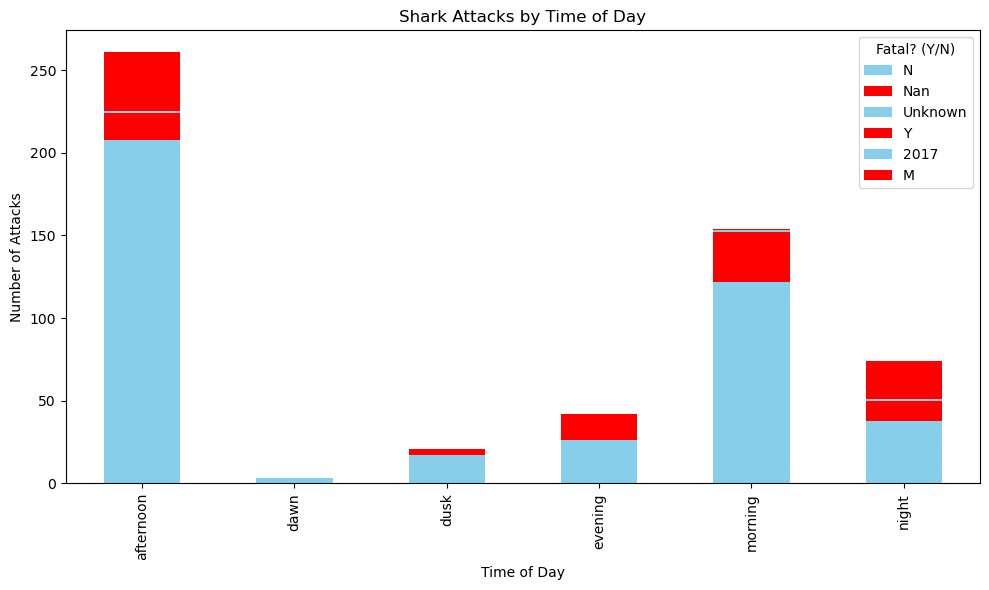

In [32]:
#Step 11: Analyze Attacks by Time of Day
#Some rows may have unclear or missing time values. We'll first clean and group the clearer ones.

# See unique time values
print(df['time'].value_counts().head(20))

#Look for clear values like "Morning", "Afternoon", "Evening", etc.

#If these are consistent, group by them:
# Simplify time column
df['time_clean'] = df['time'].str.lower().str.extract(r'(morning|afternoon|evening|dusk|dawn|night)', expand=False)

# Group and plot
time_fatal = df.groupby(['time_clean', 'fatal_y/n']).size().unstack(fill_value=0)

time_fatal.plot(kind='bar', stacked=True, figsize=(10, 6), color=['skyblue', 'red'])

plt.xlabel('Time of Day')
plt.ylabel('Number of Attacks')
plt.title('Shark Attacks by Time of Day')
plt.legend(title='Fatal? (Y/N)')
plt.tight_layout()
plt.show()


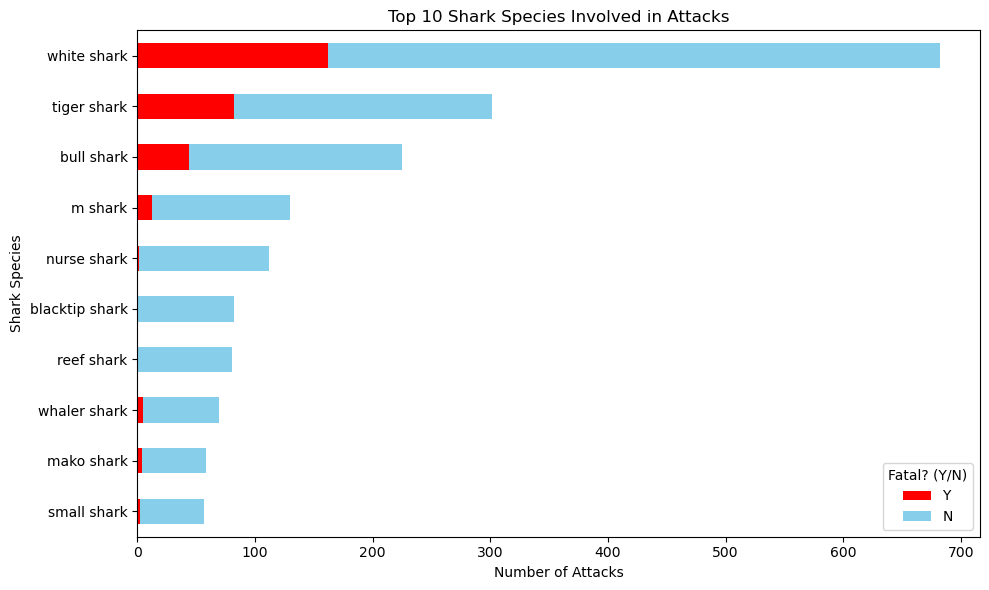

In [33]:
#Step 12: Analyze Attacks by Species (Top 10)
#We'll look at the most commonly mentioned shark species.
# Clean species column (optional)
df['species_clean'] = df['species'].str.lower().str.extract(r'(\w+ shark)', expand=False)

# Group by species and fatal
species_fatal = df.groupby(['species_clean', 'fatal_y/n']).size().unstack(fill_value=0)

# Get top 10
top10_species = species_fatal.sum(axis=1).sort_values(ascending=False).head(10)
species_top10 = species_fatal.loc[top10_species.index]

# Plot
species_top10[['Y', 'N']].plot(kind='barh', stacked=True, figsize=(10, 6), color=['red', 'skyblue'])

plt.xlabel('Number of Attacks')
plt.ylabel('Shark Species')
plt.title('Top 10 Shark Species Involved in Attacks')
plt.legend(title='Fatal? (Y/N)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Mahmoud Gobran\AppData\Local\Temp\ipykernel_35976\3531341107.py:14: SyntaxWarning: invalid escape sequence '\d'
  df['age_clean'] = df['age'].str.extract('(\d+)', expand=False)
C:\Users\Mahmoud Gobran\AppData\Local\Temp\ipykernel_35976\3531341107.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age_clean'] = df['age_clean'].astype(int)
C:\Users\Mahmoud Gobran\AppData\Local\Temp\ipykernel_35976\3531341107.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

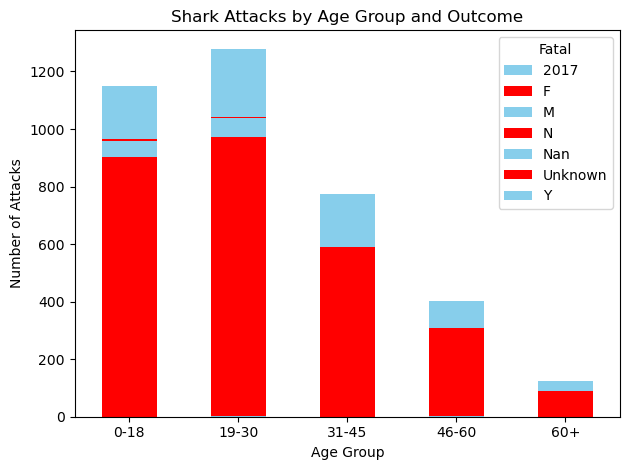

In [39]:
                                     #Age Group Analysis.
#Step 1 – Clean and Convert Age Column
#Shark attack data often has dirty age values like "35 years", "teen", "40s", or "?".

#We'll:
#Keep only numeric values
#Drop or convert unclear ages
#Convert to integer
# Make a copy of the original age column
# Convert all values in 'age' to string
df['age'] = df['age'].astype(str)

# Extract numeric part from string (e.g., "35 years" → "35")
df['age_clean'] = df['age'].str.extract('(\d+)', expand=False)

# Convert to numeric (invalid entries become NaN)
df['age_clean'] = pd.to_numeric(df['age_clean'], errors='coerce')

# Drop rows with no age
df = df.dropna(subset=['age_clean'])

# Convert to integer
df['age_clean'] = df['age_clean'].astype(int)

# Preview
df[['age', 'age_clean']].head(10)


#Step 2 – Create Age Groups
#Group into:
#0–18 (Child)
#19–30 (Young Adult)
#31–45 (Adult)
#46–60 (Older Adult)
#60+ (Senior)


#This shows:

#Which age group has the most attacks

#Which one suffers more fatal outcomes

bins = [0, 18, 30, 45, 60, 120]
labels = ['0-18', '19-30', '31-45', '46-60', '60+']

df['age_group'] = pd.cut(df['age_clean'], bins=bins, labels=labels)

df['age_group'].value_counts().sort_index()

#Step 3 – Compare Fatal vs Non-Fatal in Each Age Group
#Use a pivot table.

age_pivot = df.pivot_table(index='age_group',
                           columns='fatal_y/n',
                           values='date',
                           aggfunc='count',
                           fill_value=0)

age_pivot.plot(kind='bar', stacked=True, color=['skyblue', 'red'])

plt.title('Shark Attacks by Age Group and Outcome')
plt.xlabel('Age Group')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=0)
plt.legend(title='Fatal')
plt.tight_layout()
plt.show()


In [ ]:
                                         #Sex-based Attack Analysis
#Step 1 – Explore unique values in the sex column

df['sex'].value_counts()


sex
M      3272
F       570
Nan      33
Lli       1
Name: count, dtype: int64

In [41]:
#Step 2 – Clean the sex column
#Make all values uppercase and drop invalid ones.
# Uppercase and strip whitespace
df['sex_clean'] = df['sex'].str.upper().str.strip()

# Keep only M or F, else set to NaN
df['sex_clean'] = df['sex_clean'].where(df['sex_clean'].isin(['M', 'F']))


C:\Users\Mahmoud Gobran\AppData\Local\Temp\ipykernel_35976\691631918.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex_clean'] = df['sex'].str.upper().str.strip()
C:\Users\Mahmoud Gobran\AppData\Local\Temp\ipykernel_35976\691631918.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex_clean'] = df['sex_clean'].where(df['sex_clean'].isin(['M', 'F']))


In [42]:
#Step 3 – Count shark attacks by sex
sex_counts = df['sex_clean'].value_counts()
print(sex_counts)


sex_clean
M    3272
F     570
Name: count, dtype: int64


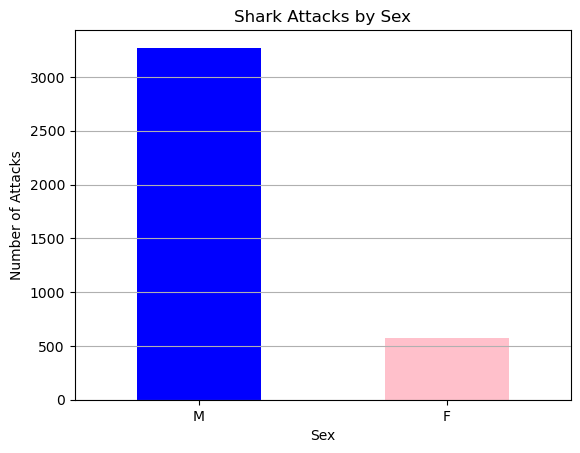

In [43]:
#Step 4 – Plot results
import matplotlib.pyplot as plt

sex_counts.plot(kind='bar', color=['blue', 'pink'])
plt.title('Shark Attacks by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()



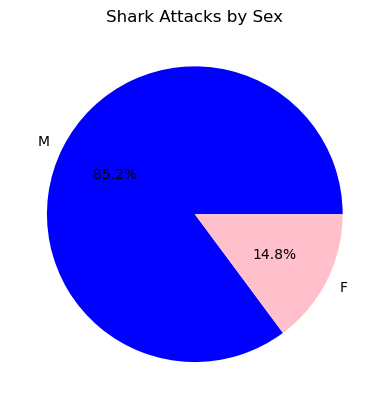

In [44]:
# Percentage breakdown
sex_counts.plot(kind='pie', autopct='%1.1f%%', colors=['blue', 'pink'])
plt.title('Shark Attacks by Sex')
plt.ylabel('')
plt.show()
